<a href="https://colab.research.google.com/github/tonmoy0018/gradient-descent-of-student-performance-without-using-built-ins/blob/main/student_performance_prediction_using_simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('StudentsPerformance.csv')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
x = np.array(df['reading score'])
y =np.array(df['math score'])

In [ ]:
def prediction(x,y,w,b):
  m = x.shape[0]
  predict = np.zeros(m)

  for i in range(m):
     predict[i] = w*x[i] + b

  return predict

In [ ]:
predict = prediction(x,y,1,1)
print(predict[1:10])

[91. 96. 58. 79. 84. 96. 44. 65. 61.]


In [ ]:
def MSE(x,y,w,b):
  m = x.shape[0]
  cost = 0.0

  for i in range(m):
    prediction =  w*x[i] + b
    error = prediction - y[i]
    squared_error = error ** 2
    cost = cost + squared_error

  cost = cost/(2*m)

  return cost


In [ ]:
MSE(x,y,1,2)

np.float64(53.406)

In [ ]:

def gradient_descent(x,y,w_input, b_input, iteration, alpha):
  w = w_input
  b = b_input
  m = x.shape[0]

  iter = []
  cost_memo = []

  dj_dw = 0.0
  dj_db = 0.0

  for i in range(iteration):
     prediction =  w*x[i] + b
     error = prediction - y[i]

     dj_dw = dj_dw+ error*x[i]
     dj_db = dj_db + error

     dj_dw = dj_dw/m
     dj_db = dj_db/m

     w = w - alpha * dj_dw
     b = w - alpha * dj_db

     if i%50 == 0:
      print(f"iteration: {i}, w:{w}, b{b}, dj_dw:{dj_dw}, dj_db:{dj_db}, cost:{MSE(x,y,w,b)}")

     iter.append(i)
     cost_memo.append(MSE(x,y,w,b))


  return w,b,cost_memo,iter


In [ ]:
w,b,cost_memo,iteration = gradient_descent(x,y,0,0,500, 0.01)

iteration: 0, w:0.051840000000000004, b0.05256, dj_dw:-5.184, dj_db:-0.072, cost:2055.8032334709787
iteration: 50, w:0.8400620109771136, b0.840123590781056, dj_dw:-0.33902868319462004, dj_db:-0.006157980394243665, cost:63.59551611562104
iteration: 100, w:0.9232910350705955, b0.9234609703970855, dj_dw:-1.1385666874641889, dj_db:-0.016993532649003978, cost:39.51248240828735
iteration: 150, w:0.978590435747449, b0.9785428349476675, dj_dw:0.31889458616054295, dj_db:0.004760079978148113, cost:43.18579784554937
iteration: 200, w:0.9144818771363823, b0.9143663625249895, dj_dw:0.9703442813966616, dj_db:0.011551461139285634, cost:40.37822415205285
iteration: 250, w:0.9874060160725007, b0.9873817992876557, dj_dw:0.11857435815719543, dj_db:0.0024216784844937216, cost:45.22305314346633
iteration: 300, w:0.9817883747583428, b0.9818250643130417, dj_dw:-0.2862162824000713, dj_db:-0.0036689554698956387, cost:43.87890188976577
iteration: 350, w:0.9413014330016358, b0.9411958104294232, dj_dw:0.686395281

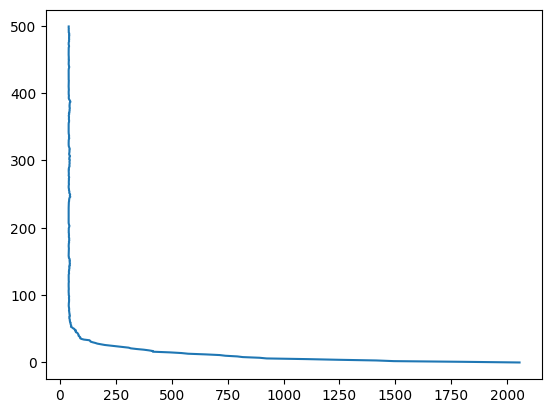

In [ ]:
plt.plot(cost_memo, iteration)